In [4]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
plt.style.use('properties.mplstyle')

In [25]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_3d.loc[:, "L":"nt_erro"]

,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,128.0,205.0,1.000000e-05,0.00010,1.0,1.0,200.0,200.0,0.520135,0.000349,205.529696,0.624733
1,128.0,205.0,1.000000e-05,0.00010,1.0,2.0,200.0,200.0,0.520619,0.000353,206.190195,0.606302
2,128.0,205.0,1.000000e-05,0.00010,1.0,3.0,200.0,200.0,0.521163,0.000393,206.746457,0.620829
3,128.0,205.0,1.000000e-05,0.00010,1.0,4.0,200.0,200.0,0.522292,0.000508,204.027648,0.629788
4,128.0,205.0,1.000000e-05,0.00100,1.0,1.0,1.0,1.0,0.511659,0.000000,200.550000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2814,512.0,3270.0,1.000000e-07,0.22718,1.0,3.0,5.0,3.0,1.000000,0.000000,845.184579,162.849525
2815,512.0,3270.0,1.000000e-07,0.22718,1.0,4.0,5.0,1.0,1.000000,0.000000,771.932217,0.000000
2816,512.0,3270.0,1.000000e-07,0.22742,1.0,1.0,5.0,5.0,1.000000,0.000000,402.488825,72.649900
2817,512.0,3270.0,1.000000e-07,0.22742,1.0,2.0,5.0,2.0,1.000000,0.000000,503.557886,272.377661


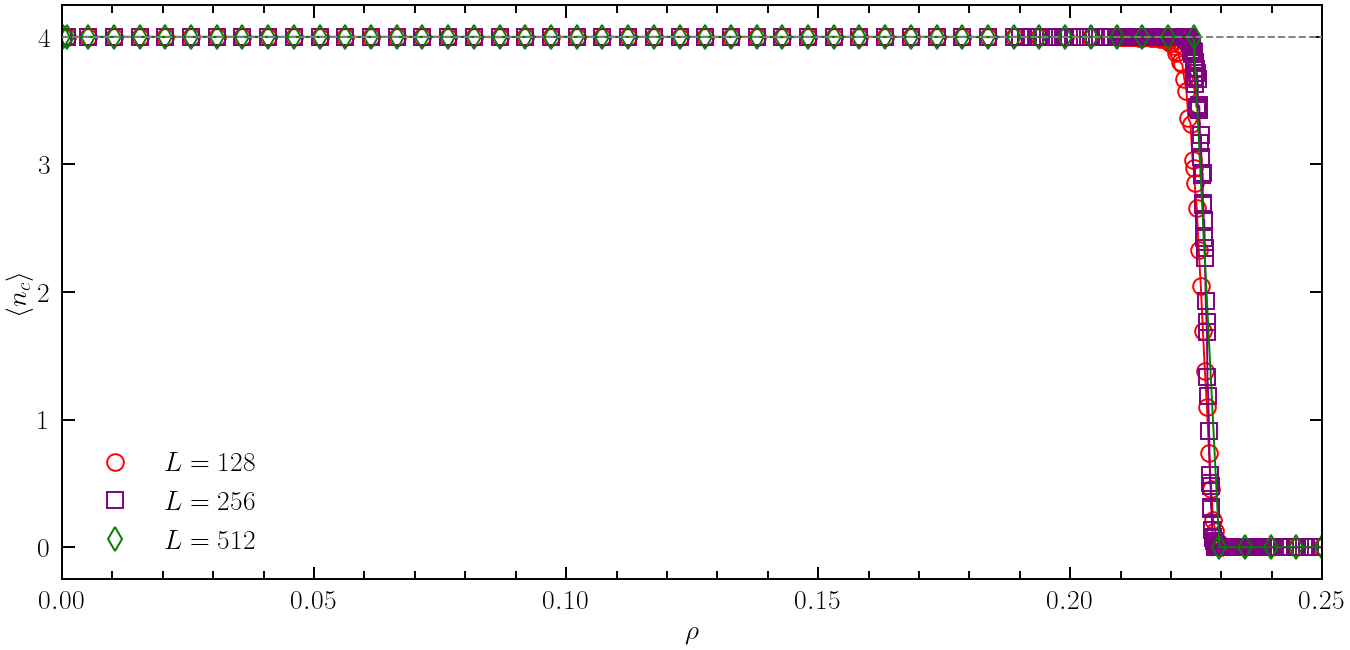

In [8]:
p0_filter = 1.0
L_values = [128, 256, 512]
k_values = [1.0e-04, 1.0e-06, 1.0e-07]

ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]   # formatos do PLOT (linha + marcador)
mew = 1.4
thickness = 1.4

assert len(L_values) == len(k_values), "L_values e k_values devem ter o mesmo tamanho."

fig, ax = plt.subplots(figsize=(14,7))
legend_handles = []

for idx, (L, kval) in enumerate(zip(L_values, k_values)):
    res = mean_nc_by_rho(df_all_3d, num_colors=4,
                         p0_filter=p0_filter, L_filter=L, k_filter=kval)
    if res.empty:
        print(f"[WARN] sem dados para L={L}, k={kval}")
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    # --- PLOT (não altera marcador: fica EXATAMENTE como você definiu) ---
    line, = ax.plot(res["rho"], res["nc_mean"], fmt,
                    color=color, linewidth=thickness,
                    ms=ms, markeredgewidth=mew, zorder=2)

    # --- HANDLE da LEGENDA copiando PROPRIEDADES do plot (sem mudanças) ---
    handle = Line2D(
        [0], [0],
        linestyle='None',
        marker=line.get_marker(),
        markersize=ms,
        markeredgewidth=line.get_markeredgewidth(),
        markeredgecolor=line.get_markeredgecolor(),
        markerfacecolor=line.get_markerfacecolor(),      # pode ser 'none' — mantemos
        fillstyle=line.get_fillstyle(),
        alpha=(line.get_alpha() if line.get_alpha() is not None else 1.0),
        color=line.get_color(),
        label=fr"$L = {L}$",
    )
    legend_handles.append(handle)

# Linha guia por cima e limites
ax.set_xlim(0.0, 0.25)
ax.axhline(y=4, xmin=0.0, xmax=1.0, color='gray', linestyle='--', lw=1.4, zorder=100)

# Rótulos e limites
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, 4.25])

# Ticks
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_major_locator(MultipleLocator(1.0))
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

# Borda (spines) mais espessa
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

# Legenda com os handles customizados (marcador idêntico ao do plot)
ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left")

plt.tight_layout()
plt.show()


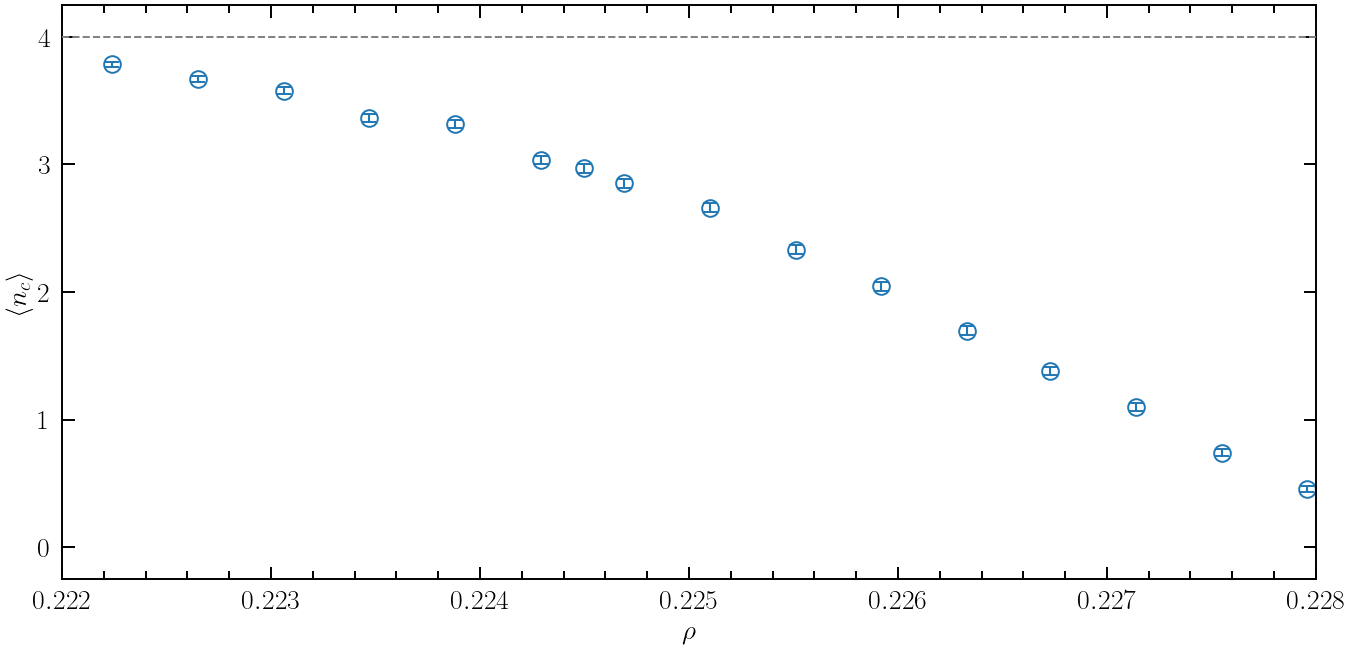

In [28]:
p0_filter = 1.0

k = []
L_values = [128, 256, 512]
k_values = [1.0e-04, 1.0e-05, 1.0e-07]

res_512 = mean_nc_by_rho(df_all_3d, num_colors=4, p0_filter=p0_filter, L_filter=L_values[0], k_filter=k_values[0])

ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 15
colors = ["red", "purple", "green", "blue"]
marker = ["o-", "s-", "d-", "^-"]

mew = 1.4
thickness = 1.4

fig, ax = plt.subplots(figsize=(14,7))

# Curvas com zorder baixo
# ln128, cap128, bar128 = ax.errorbar(
#     res_128["rho"], res_128["nc_mean"], yerr=res_128["nc_sem"],
#     fmt="^-", capsize=5, label=r'$L = 128$', ms=ms, zorder=2,
#     markeredgewidth=mew
# )
# ln256, cap256, bar256 = ax.errorbar(
#     res_256["rho"], res_256["nc_mean"], yerr=res_256["nc_sem"],
#     fmt="o-", capsize=5, label=r'$L = 256$', ms=ms, zorder=2,
#     markeredgewidth=mew
# )

ln512, cap512, bar512 = ax.errorbar(
    res_512["rho"], res_512["nc_mean"], yerr=res_512["nc_sem"],
    fmt="o", capsize=5, label=r'$L = 512$', ms=ms, zorder=2,
    markeredgewidth=mew
)

# Garantir que caplines e barras de erro não fiquem acima da linha
# for coll in (cap128, bar128, cap256, bar256, cap512, bar512):
#     for artist in coll:
#         artist.set_zorder(2)

for coll in (cap512, bar512):
    for artist in coll:
        artist.set_zorder(2)
# Limites em coordenadas de dados até 0.25
ax.set_xlim(0.0, 0.25)

# Linha horizontal por cima de tudo
ax.axhline(y=4, xmin=0.0, xmax=1.0, color='gray', linestyle='--', lw=1.4, zorder=100)

ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, 4.25])

# Opcional: ticks maiores
ax.tick_params(axis='both', labelsize=font_tick_size)
ax.xaxis.set_minor_locator(AutoMinorLocator())

# Y: major ticks a cada 1 unidade
ax.yaxis.set_major_locator(MultipleLocator(1.0))

# Opcional: ajuste visual dos ticks
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)   # only x minor
# Define a espessura das bordas
for spine in ax.spines.values():
    spine.set_linewidth(thickness)
ax.set_xlim([0.222, 0.228])

plt.tight_layout()
plt.show()

In [13]:
# Ex.: res_256 = mean_nc_by_rho_robust(..., L_filter=256, p0_filter=1.0)
rho_lo, rho_hi, _ = find_drop_interval(res_512, num_colors=4, frac_hi=0.98, frac_lo=0.02,
                                       smooth_window=5, pad=0.002)
print("Intervalo alvo:", rho_lo, rho_hi)

# Gere um grid mais denso (40 pontos por padrão) apenas nessa faixa:
rho_targets = make_refined_rho_grid(rho_lo, rho_hi, n_points=60)  # aumente se quiser ainda mais denso
print(rho_targets[:5], "...", rho_targets[-5:])

Intervalo alvo: 0.0001 0.2316
[0.0001     0.00402373 0.00794746 0.01187119 0.01579492] ... [0.21590508 0.21982881 0.22375254 0.22767627 0.2316    ]
